# Laboratorio 2022-22

## Sesión 13: Dinámica de poblaciones: matrices de Markov ##

**Ejercicio 1.** En la lectura previa a esta sesión hemos visto un criterio para saber si una matriz estocástica dada es o no regular.

**Teorema.** _Una matriz estocástica $M$ de orden $n$ es regular si y solo si todos los elementos de $M^{n^2}$ son positivos_

En particular, para ver si una matriz de Markov es o no regular basta con ir calculando potencias de $M$ hasta o bien llegar a una con todas sus entradas positivas, o bien alcanzar la potencia $n^2$ sin que esto ocurra, en cuyo caso $M$ será no regular. De hecho, mientras no busquemos la menor potencia que nos asegura que la matriz es regular, podemos _acelerar_ el cálculo considerando solo las potencias de la forma $2^k$, para lo que basta con tomar el cuadrado de la potencia previa de esta forma: $M^{2^k}=\big(M^{2^{k-1}}\big)^2$.

**a)** Codifica una función que dada una matriz estocástica decida si es o no regular utilizando el resultado previo y el cálculo acelerado. La función, digamos $\texttt{EsRegular}()$, recibirá una matriz estocástica y devolverá $\texttt{True}$ si es regular y $\texttt{False}$ en caso contrario. 

_Sugerencia_: dada una matriz $M$, $M\texttt{.nonzero}\_\texttt{positions}()$ devuelve una lista de pares $(i,j)$ que indican las posiciones en la matriz no nulas.

In [83]:
def EsRegular(M):
    k=1
    lista=[]
    c=False
    while 2^(k-1)<=M.nrows() and c!=True: 
        print(k)
        if len(M.𝚗𝚘𝚗𝚣𝚎𝚛𝚘_𝚙𝚘𝚜𝚒𝚝𝚒𝚘𝚗𝚜())==M.nrows()*M.nrows():
            c=True
        n = (2^(k-1))^2
        #print(n)
        M=M^n
        k=k+1
    return c

In [85]:
M=matrix([[1,0],[0,1]])
EsRegular(M)

1
2


False

**b)** Comprueba con la función del apartado anterior si es regular la siguiente matriz y en caso afirmativo calcular la menor potencia de la matriz con todas sus entradas positivas.
$$\left(\begin{array}{rrrrrrrrr}
\frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} & \frac{9}{10} \\
\frac{1}{10} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & \frac{1}{10} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & \frac{1}{10} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{10} & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{10} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{10} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{10} & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{10} & \frac{1}{10}
\end{array}\right)$$

In [86]:
B=matrix([[9/10,9/10,9/10,9/10,9/10,9/10,9/10,9/10,9/10,9/10],[1/10,0,0,0,0,0,0,0,0,0],[0,1/10,0,0,0,0,0,0,0,0],[0,0,1/10,0,0,0,0,0,0,0],[0,0,0,1/10,0,0,0,0,0,0],[0,0,0,0,1/10,0,0,0,0,0],[0,0,0,0,0,1/10,0,0,0,0],[0,0,0,0,0,0,1/10,0,0,0],[0,0,0,0,0,0,0,1/10,0,0],[0,0,0,0,0,0,0,0,1/10,1/10]])

In [87]:
EsRegular(B)

1
2
3
4


True

**Ejercicio 2.** Estamos diseñando el sistema de ascensores de un rascacielos.

La empresa que los fabrica nos dice que cada día tendrán que parar, por avería o mantenimiento, el $10\%$ de los ascensores que estuviesen funcionando el día anterior, y que el $70\%$ de los ascensores que estén parados en un día dado volverán a estar operativos al día siguiente.

**a)**  Tras el periodo inicial de ajuste, ¿llegaremos a un régimen estable de funcionamiento de los ascensores? (*Sugerencia:* Estudiar la evolución del modelo matricial para este problema.)


In [78]:
M=matrix([[0.9,0.7],[0.1,0.3]])
show(M)

[0.900000000000000 0.700000000000000]
[0.100000000000000 0.300000000000000]

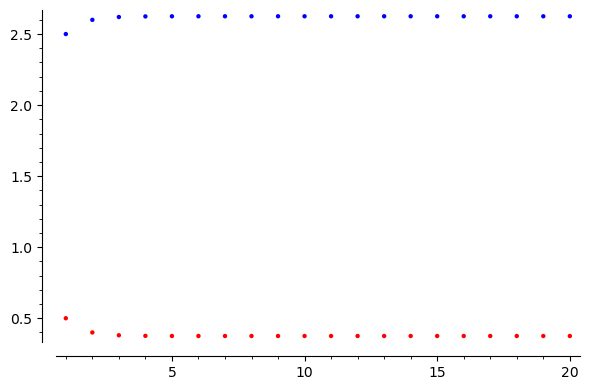

In [121]:
u=vector((0,0))
v=vector((2,1))
M=matrix([[0.9,0.7],[0.1,0.3]])

X=[]
Y=[]
for j in [1..20]:
    v=M*v
    X.append((j,v[0])) #Funcionando
    Y.append((j,v[1])) #En mantenimiento

points(X,color='blue')+points(Y,color='red')

**b)** ¿Cuántos ascensores tendremos que instalar en el rascacielos si queremos que haya habitualmente 15 en condiciones de funcionar?

18


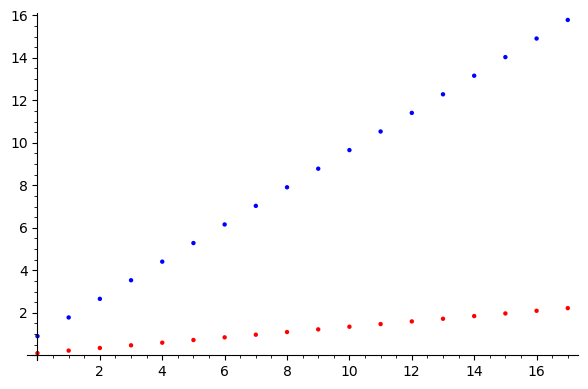

In [122]:
u=vector((0,0))

X=[]
Y=[]
j=0
while u[0]<15:
    u[0]=u[0]+1
    u=M*u
    X.append((j,u[0])) #Funcionando
    Y.append((j,u[1])) #En mantenimiento  
    j=j+1
print(j)
points(X,color='blue')+points(Y,color='red')
    

**Ejercicio 3.** _Otra matriz de Markov_

En una parcela dedicada a la explotación forestal, los árboles se clasifican según su tamaño en tres tipos: Pequeños, Medianos y Grandes. Cada periodo de 5 años, la evolución del bosque es la siguiente:

- El 20% de los árboles Pequeños no han crecido lo suficiente, y siguen siendo Pequeños. El 70% han pasado a la categoría de Medianos, y un 10% ha tenido un crecimiento excepcional que les hace pasar a la categoría de Grandes.

- El 10% de los árboles Medianos siguen siendo Medianos, y el 90% restante pasan a ser Grandes.

- Se tala el 80% de los árboles Grandes.

- Se plantan tantos árboles Pequeños como árboles Grandes han sido talados.

- Se considera que ningún árbol muere por ninguna otra causa que no sea la tala.

**Comentario:** Observa que como se plantan tantos árboles como son talados, el número total de árboles es constante en cada periodo de 5 años. Estamos de nuevo ante una matriz de Markov.

**a)** Denotando por $P_N, M_N, G_N $ el número de árboles en cada categoría en el _lustro_ $N$ (lustro = 5 años), formula matricialmente el sistema y estudia su evolución a largo plazo, para determinar qué porcentaje de árboles se espera que estén en cada una de las categorías.</p>


In [111]:
M=matrix([[0.2,0,0.8],[0.7,0.1,0],[0.1,0.9,0.2]])
show(M)

[0.200000000000000 0.000000000000000 0.800000000000000]
[0.700000000000000 0.100000000000000 0.000000000000000]
[0.100000000000000 0.900000000000000 0.200000000000000]

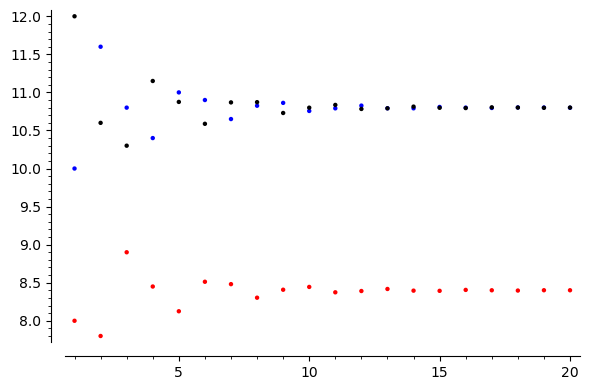

In [115]:
u=vector((0,0,0))
v=vector((10,10,10))

X=[]
Y=[]
Z=[]
for j in [1..20]:
    v=M*v
    X.append((j,v[0])) 
    Y.append((j,v[1])) 
    Z.append((j,v[2]))

points(X,color='blue')+points(Y,color='red')+points(Z,color='black')

**b)** Por consideraciones de tipo paisajístico, se desea que a largo plazo el porcentaje de árboles grandes sea del 50%. Calcula el porcentaje de tala exacto para cumplir este objetivo.

_Sugerencia:_ Utilizar una matriz con una variable en las posiciones adecuadas. Para conseguir resultados exactos, conviene escribir los datos numéricos de la matriz en notación racional e indicar que se trabaja en el anillo simbólico $\texttt{SR}$.

In [137]:
#Ver Soluciones
var('t')
M=matrix(SR,3,[[0.2,0,t],[0.7,0.1,0],[0.1,0.9,1-t]])

IndexError: list index out of range

In [119]:
u=vector((0,0,0))
v=vector((10,10,10))

X=[]
Y=[]
Z=[]
t=0
while v[2]!=v[0]/2:
    v=M*v
    X.append((j,v[0])) 
    Y.append((j,v[1])) 
    Z.append((j,v[2]))
    
points(X,color='blue')+points(Y,color='red')+points(Z,color='black')

KeyboardInterrupt: 

IndexError: list index out of range